<a href="https://colab.research.google.com/github/thibaultpelenc-sys/Lab_Visualisation2/blob/main/mp.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Visualização do dataset `mtcars`

Notebook R compatível com Google Colab.

In [ ]:
if (!require(tidyverse)) install.packages("tidyverse")
if (!require(scales)) install.packages("scales")
if (!require(ggthemes)) install.packages("ggthemes")
if (!require(maps)) install.packages("maps") # Permet d'avoir le fond de carte du monde

library(tidyverse)
library(scales)
library(ggthemes)
library(maps)

In [ ]:
# 1. Charger la population par commune (tabela6579 (1).csv)
df_pop <- read_delim("tabela6579 (1).csv", delim = ";", skip = 3,
                     col_names = c("rank", "municipio", "population")) %>%
  filter(municipio != "Município" & !is.na(rank)) %>%
  mutate(population = as.numeric(population))

# 2. Charger le PIB par commune (tabela5938.csv)
df_pib <- read_csv("tabela5938.csv", skip = 3,
                   col_names = c("municipio", "pib_total")) %>%
  filter(!municipio %in% c("Brasil e Município", "Brasil")) %>%
  mutate(pib_total = as.numeric(pib_total))

print("Les communes ont été chargées avec succès !")

Warning message:
“One or more parsing issues, call `problems()` on your data frame for details,
e.g.:
  dat <- vroom(...)
  problems(dat)”
Rows: 5748 Columns: 3
── Column specification ────────────────────────────────────────────────────────
Delimiter: ";"
chr (2): rank, municipio
dbl (1): population

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Warning message:
“One or more parsing issues, call `problems()` on your data frame for details,
e.g.:
  dat <- vroom(...)
  problems(dat)”
Rows: 5586 Columns: 2
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (2): municipio, pib_total

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Warning message:
“There was 1 warning in `mutate()`.
ℹ In argument: `pib_total = as.numeric(pib_total

[1] "Les communes ont été chargées avec succès !"


In [ ]:
# Téléchargement des tables de coordonnées géographiques
url_coords <- "https://raw.githubusercontent.com/kelvins/Municipios-Brasileiros/main/csv/municipios.csv"
url_estados <- "https://raw.githubusercontent.com/kelvins/Municipios-Brasileiros/main/csv/estados.csv"

coords <- read_csv(url_coords)
estados <- read_csv(url_estados)

# Création du dictionnaire géolocalisé
coords_br <- coords %>%
  inner_join(estados, by = "codigo_uf") %>%
  mutate(municipio = paste0(nome.x, " (", uf, ")")) %>%
  select(municipio, uf, latitude = latitude.x, longitude = longitude.x)

# Fusion globale
dados_complets <- df_pop %>%
  inner_join(df_pib, by = "municipio") %>%
  inner_join(coords_br, by = "municipio") %>%
  filter(!is.na(population) & !is.na(pib_total)) %>%
  mutate(PIB_per_capita = (pib_total * 1000) / population)

# C'est ici qu'on sélectionne uniquement les 5 plus grandes villes de chaque État (uf)
dados_filtrés <- dados_complets %>%
  group_by(uf) %>%
  slice_max(order_by = population, n = 50) %>%
  ungroup()

print(paste("Filtrage réussi ! Nombre de points retenus sur la carte (5 par état maximum) :", nrow(dados_filtrés)))

Rows: 5571 Columns: 9
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (3): nome, siafi_id, fuso_horario
dbl (6): codigo_ibge, latitude, longitude, capital, codigo_uf, ddd

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Rows: 27 Columns: 6
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (3): uf, nome, regiao
dbl (3): codigo_uf, latitude, longitude

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


[1] "Filtrage réussi ! Nombre de points retenus sur la carte (5 par état maximum) : 1203"


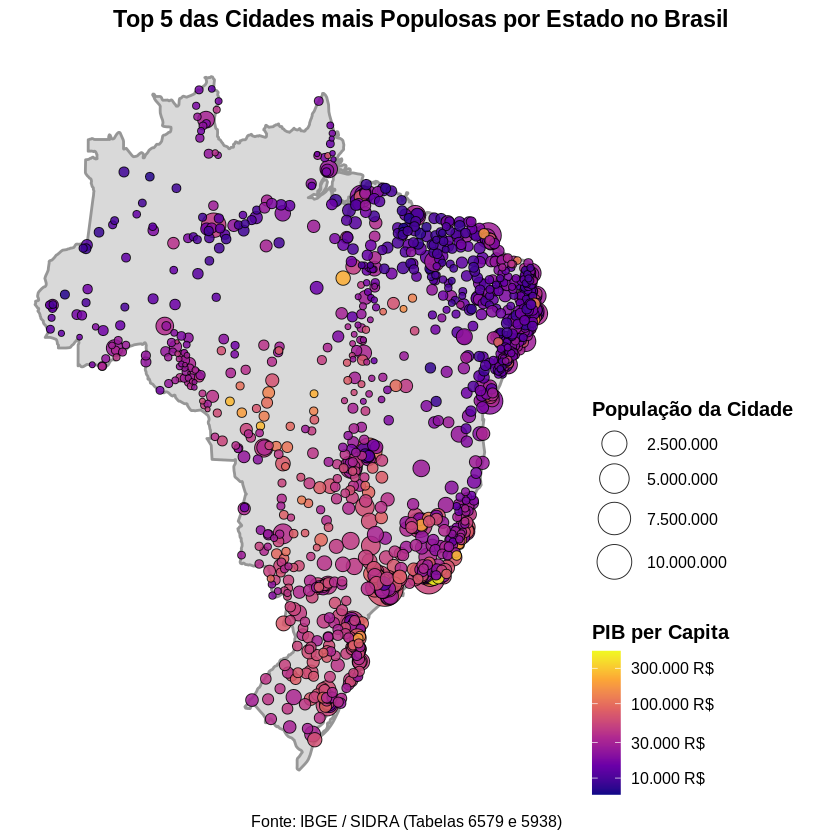

In [ ]:
library(ggplot2)

# Récupération des frontières du Brésil pour le fond de carte
fond_bresil <- map_data("world", region = "Brazil")

carte_allégée <- ggplot() +
  # 1. TRACÉ DU FOND DE CARTE
  geom_polygon(
    data = fond_bresil,
    aes(x = long, y = lat, group = group),
    fill = "#d9d9d9",
    color = "#969696",
    size = 0.8
  ) +

  # 2. TRACÉ DES POINTS
  geom_point(
    data = dados_filtrés,
    aes(x = longitude, y = latitude, size = population, fill = PIB_per_capita),
    shape = 21,
    color = "black",
    stroke = 0.4,
    alpha = 0.85,
    position = position_jitter(width = 0.05, height = 0.05, seed = 42)
  ) +

  # Échelle de couleur Plasma (Log10)
  scale_fill_gradientn(
    colors = c("#0d0887", "#6a00a8", "#b12a90", "#e16462", "#fca636", "#f0f921"),
    name = "PIB per Capita",
    trans = "log10",
    labels = label_number(big.mark = ".", decimal.mark = ",", suffix = " R$")
  ) +

  # Échelle de taille Racine Carrée
  scale_size_continuous(
    name = "População da Cidade",
    trans = "sqrt",
    range = c(0.5, 10.0),
    labels = label_number(big.mark = ".", decimal.mark = ",")
  ) +

  # Titres et style de la carte
  labs(
    title = "Top 5 das Cidades mais Populosas por Estado no Brasil",
    x = "Longitude",
    y = "Latitude",
    caption = "Fonte: IBGE / SIDRA (Tabelas 6579 e 5938)"
  ) +
  theme_map(base_size = 12) +
  theme(
    # --- LES MODIFICATIONS SONT ICI ---
    plot.title.position = "plot",      # Aligne le titre sur l'ensemble de l'image (légende incluse)
    plot.title = element_text(face = "bold", size = 14, hjust = 0.5), # hjust = 0.5 centre le texte
    plot.subtitle = element_text(size = 10, hjust = 0.5, face = "italic"), # Centrage du sous-titre aussi

    legend.position = "right",
    legend.title = element_text(face = "bold")
  )

# Affichage du graphique final
carte_allégée

In [ ]:
if (!require(svglite)) install.packages("svglite")

ggsave(
  filename = "visualizacao-top5-brasil.svg",
  plot = carte_allégée,
  width = 11,
  height = 8
)

cat("Le fichier 'visualizacao-top5-brasil.svg' a été généré avec succès !\n")

Le fichier 'visualizacao-top5-brasil.svg' a été généré avec succès !
